# Effect of Shear Deformation: Euler–Bernoulli vs. Timoshenko

**Case:** `uniform_shafts / point_load / case_radial_single_position`
**Study type:** model comparison (study, not validation)
**Status:** provisional

## Question

What is the contribution of shear deformation to the deflection of this
shaft ($L/d = 10$), and how much do the two shear correction factors
available in AxisForge (Cowper, Hutchinson) differ?

## Method in brief

The same resolved system (geometry, supports, gear mesh loads) is solved
with three beam models — Euler–Bernoulli (EB) and Timoshenko with the
Cowper and Hutchinson shear correction factors $\kappa$ — on the
**minimal mesh** (mandatory nodes only). Mesh convergence of the
Timoshenko element is treated separately in notebook 02 (GCI study);
here the discretisation error on the minimal mesh is quantified against
the closed-form solution, so that it is not mistaken for a physical
effect.

In [1]:
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from validation._support.figures import shaft_studies as fg
from references.beams import uniform_beam as an
import construction as cd

fg.use_style()
pd.set_option("display.float_format", lambda v: f"{v:.4g}")

## 1. Case definition

All input data are taken from `construction.py`; nothing is
redeclared in this notebook.

In [2]:
props = cd.section_properties()
system = cd.build_system()

inputs = pd.DataFrame(
    [
        ("Shaft length", "L", cd.SHAFT_LENGTH_MM, "mm"),
        ("Diameter (solid)", "d", cd.SHAFT_DIAMETER_MM, "mm"),
        ("Material", "—", cd.MATERIAL_ID, "—"),
        ("Young's modulus", "E", props.E, "MPa"),
        ("Poisson's ratio", "ν", props.nu, "—"),
        ("Shear modulus", "G", props.G, "MPa"),
        ("Locating bearing (6204)", "x_A", cd.BALL_POSITION_MM, "mm"),
        ("Non-locating bearing (NU204)", "x_B", cd.ROLLER_POSITION_MM, "mm"),
        ("Test load", "F", cd.TEST_LOAD_N, "N"),
        ("Transmitted power", "P", cd.POWER_W / 1e3, "kW"),
    ],
    columns=["Quantity", "Symbol", "Value", "Unit"],
)
inputs

,Quantity,Symbol,Value,Unit
0,Shaft length,L,200,mm
1,Diameter (solid),d,20,mm
2,Material,—,S355,—
3,Young's modulus,E,2.1e+05,MPa
4,Poisson's ratio,ν,0.3,—
5,Shear modulus,G,8.077e+04,MPa
6,Locating bearing (6204),x_A,10,mm
7,Non-locating bearing (NU204),x_B,190,mm
8,Test load,F,500,N
9,Transmitted power,P,10.47,kW


Radial loads acting on each shaft once the gear mesh has been resolved
(`source = "gear_mesh"`), decomposed into the two bending planes:

In [3]:
from axisforge.core.loads import LoadPlane

rows = []
for ss in system.shafts:
    for ld in ss.radial_loads:
        rows.append((ss.name, ld.label or "—", ld.source, ld.position,
                     float(ld.magnitude), float(ld.component(LoadPlane.XY)),
                     float(ld.component(LoadPlane.XZ))))
loads = pd.DataFrame(rows, columns=["Shaft", "Load", "Source", "x / mm",
                                    "|F| / N", "F_xy / N", "F_xz / N"])
loads

,Shaft,Load,Source,x / mm,|F| / N,F_xy / N,F_xz / N
0,shaft1,radial_test_load,user,60,500,-9.185e-14,-500
1,shaft1,g_driver:Fr,gear_mesh,100,1820,1820,0
2,shaft1,g_driver:Ft,gear_mesh,100,5000,3.062e-13,5000
3,shaft2,g_driven:Fr,gear_mesh,100,1820,-1820,2.229e-13
4,shaft2,g_driven:Ft,gear_mesh,100,5000,3.062e-13,5000
5,shaft2,radial_test_load,user,140,500,-9.185e-14,-500


**Remark on the case design.** The two test-load positions (60 and
140 mm) are symmetric about mid-span (100 mm), and so are the supports
(10 / 190 mm). The two shafts are therefore mirror images of each other
as far as the resultant deflection is concerned. Moreover, the test load
(500 N) is about 10 % of the tangential gear mesh force (5 kN). The case
is a good test of the solver, but it isolates the effect of load
position only weakly.

## 2. Theoretical background

**Euler–Bernoulli.** Plane cross-sections remain perpendicular to the
neutral axis:

$$ EI\,\frac{d^2 v}{dx^2} = M(x). $$

**Timoshenko.** The cross-section rotation $\theta$ is independent of
the slope $dv/dx$; the difference is the shear strain, taken as uniform
over the section after applying the correction factor $\kappa$:

$$ EI\,\frac{d\theta}{dx} = M, \qquad
   \gamma = \frac{dv}{dx} - \theta = \frac{V}{\kappa G A}, \qquad
   V = -\frac{dM}{dx}. $$

For a statically determinate beam the deflection splits into
$v = v_b + v_s$, with $v_s = -M/(\kappa G A) + C_1 x + C_2$: the shear
contribution **always adds** to the bending contribution and never
reduces it.

**Order of magnitude.** For a simply supported beam with a mid-span
load, the ratio of the two contributions is

$$ \frac{v_s}{v_b} = \frac{12\,EI}{\kappa G A\,\ell^2}, $$

where $\ell$ is the span between supports.

**Shear correction factors, solid circular section:**

$$ \kappa_\text{Cowper} = \frac{6(1+\nu)}{7+6\nu} \quad\text{(Cowper, 1966)}, \qquad
   \kappa_\text{Hutchinson} = \frac{6(1+\nu)^2}{7+12\nu+4\nu^2} \quad\text{(Hutchinson, 2001)}. $$

**Static determinacy.** With two simple supports, the reactions and
$M(x)$ follow from equilibrium alone and are therefore **identical for
all three models**; only the deflections and rotations change. This
provides an immediate check on the numerical results.

In [4]:
span = cd.ROLLER_POSITION_MM - cd.BALL_POSITION_MM
kappa = {name: f(props.nu) for name, f in an.KAPPA.items()}
ratio = {name: 12 * props.EI / (k * props.GA * span**2) for name, k in kappa.items()}

from axisforge.mesh.shaft.element_type.shear_factor import ShearFactor  # cross-check
sf = ShearFactor()
assert np.isclose(kappa["cowper"], sf.cowper_factor(props.nu))
assert np.isclose(kappa["hutchinson"], sf.hutchinson_factor(props.nu))

pd.DataFrame({"κ": kappa, "κGA / N": {n: k * props.GA for n, k in kappa.items()},
              "v_s / v_b (estimate)": ratio})

,κ,κGA / N,v_s / v_b (estimate)
cowper,0.8864,2.249e+07,0.02716
hutchinson,0.9252,2.348e+07,0.02602


In [5]:
display(Markdown(
    f"The estimate predicts a shear-induced increase in deflection of approximately "
    f"**{100 * ratio['cowper']:.1f} %** (Cowper) and "
    f"**{100 * ratio['hutchinson']:.1f} %** (Hutchinson). The two factors differ by "
    f"{100 * abs(kappa['cowper'] / kappa['hutchinson'] - 1):.1f} %, but this difference "
    f"affects only the shear contribution; the difference in total deflection is "
    f"therefore expected to be of the order of "
    f"{100 * abs(ratio['cowper'] - ratio['hutchinson']):.2f} percentage points."
))

The estimate predicts a shear-induced increase in deflection of approximately **2.7 %** (Cowper) and **2.6 %** (Hutchinson). The two factors differ by 4.2 %, but this difference affects only the shear contribution; the difference in total deflection is therefore expected to be of the order of 0.11 percentage points.

## 3. Mesh

Only the mandatory nodes are used: shaft ends, bearing centres and
extents, gear centre and face-width limits, and load positions. The
Euler–Bernoulli element (cubic Hermite) is nodally exact on this mesh.
The Timoshenko element is a two-node linear element with reduced shear
integration (`single_point`) and carries a discretisation error on this
mesh, quantified in Section 4.3 and studied in notebook 02.

In [6]:
results = {name: cd.solve(system, settings) for name, settings in cd.THEORIES.items()}
r0 = results["euler_bernoulli"]["shaft1"]
display(Markdown(f"Minimal mesh: **{len(r0.x_nodes)} nodes**, "
                 f"element length {np.min(np.diff(r0.x_nodes)):.1f}–{np.max(np.diff(r0.x_nodes)):.1f} mm."))

Minimal mesh: **12 nodes**, element length 3.0–75.5 mm.

## 4. Results

### 4.1 Static determinacy check

The reactions must coincide across models to round-off precision. The
maximum bending moment must coincide as well, apart from a sampling
deviation: in the linear Timoshenko element $M = EI\,d\theta/dx$ is
constant within each element, so the peak of $M$ under a point load is
underestimated by $\mathcal{O}(h)$ (≈ $|dM/dx|\,h/2$).

In [7]:
rows = []
for name, res in results.items():
    for shaft, r in res.items():
        R_A, R_B = (b.Fr for b in r.bearing_nodes)
        rows.append((shaft, name, R_A, R_B, r.v_max, r.x_v_max, r.M_max))
summary = pd.DataFrame(rows, columns=["Shaft", "Model", "R_A / N", "R_B / N", "v_max / mm",
                                      "x(v_max) / mm", "M_max / N·mm"])
eb = summary[summary["Model"] == "euler_bernoulli"].set_index("Shaft")
summary["Δv_max vs EB / %"] = [100 * (row["v_max / mm"] / eb.loc[row["Shaft"], "v_max / mm"] - 1)
                               for _, row in summary.iterrows()]
summary["ΔM_max vs EB / %"] = [100 * (row["M_max / N·mm"] / eb.loc[row["Shaft"], "M_max / N·mm"] - 1)
                               for _, row in summary.iterrows()]
summary

,Shaft,Model,R_A / N,R_B / N,v_max / mm,x(v_max) / mm,M_max / N·mm,Δv_max vs EB / %,ΔM_max vs EB / %
0,shaft1,euler_bernoulli,2324,2530,0.3662,100,2.277e+05,0,0
1,shaft2,euler_bernoulli,2530,2324,0.3662,100,2.277e+05,0,0
2,shaft1,timoshenko/cowper,2324,2530,0.3413,100,2.182e+05,-6.798,-4.167
3,shaft2,timoshenko/cowper,2530,2324,0.3405,100,2.182e+05,-7.009,-4.167
4,shaft1,timoshenko/hutchinson,2324,2530,0.3409,100,2.182e+05,-6.914,-4.167
5,shaft2,timoshenko/hutchinson,2530,2324,0.3401,100,2.182e+05,-7.125,-4.167


### 4.2 Deflection along the shaft

Upper panel: resultant deflection $v = \sqrt{v_{xy}^2 + v_{xz}^2}$.
Lower panel: increase relative to the EB solution, normalised by the
maximum EB deflection (rather than point by point, which is undefined at
the supports, where $v = 0$).

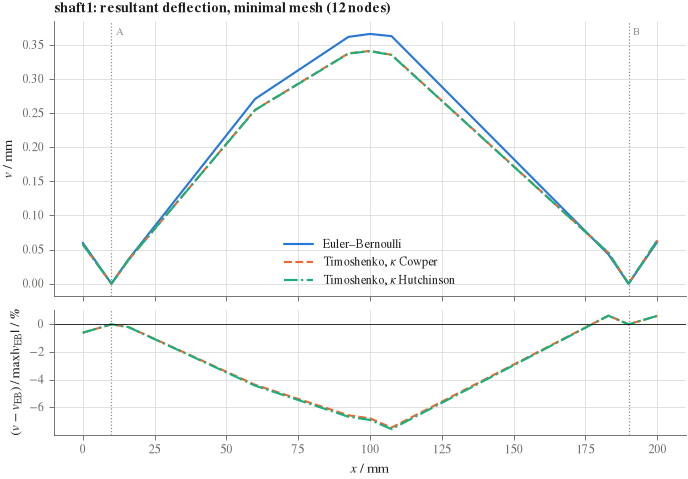

In [8]:
STYLE = {
    "euler_bernoulli": dict(label="Euler–Bernoulli", color="#2a78d6", linestyle="-"),
    "timoshenko/cowper": dict(label=r"Timoshenko, $\kappa$ Cowper", color="#eb6834", linestyle="--"),
    "timoshenko/hutchinson": dict(label=r"Timoshenko, $\kappa$ Hutchinson", color="#1baf7a", linestyle="-."),
}

def shear_figure(shaft: str):
    ref = results["euler_bernoulli"][shaft]
    scale = np.max(np.abs(ref.v))
    series, deltas = [], []
    for name, res in results.items():
        r = res[shaft]
        series.append(fg.Series(x=r.x, y=r.v, **STYLE[name]))
        if name != "euler_bernoulli":
            deltas.append(fg.Series(x=r.x, y=100 * (np.asarray(r.v) - np.asarray(ref.v)) / scale,
                                    **STYLE[name]))
    return fg.field_comparison(
        series, deltas,
        title=f"{shaft}: resultant deflection, minimal mesh ({len(results['euler_bernoulli'][shaft].x_nodes)} nodes)",
        ylabel=r"$v$ / mm",
        delta_label=r"$(v - v_\mathrm{EB})\,/\,\max|v_\mathrm{EB}|$ / %",
        supports=(cd.BALL_POSITION_MM, cd.ROLLER_POSITION_MM), support_names=("A", "B"),
    )

fig_shaft1 = shear_figure("shaft1")

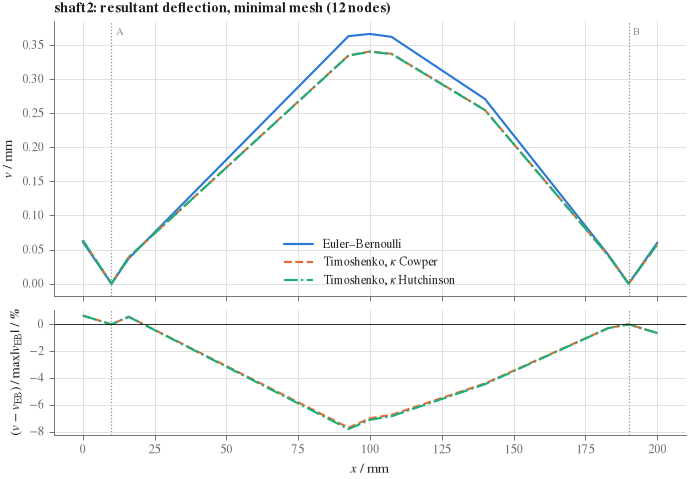

In [9]:
fig_shaft2 = shear_figure("shaft2")

### 4.3 Comparison with the analytical solution

Each FEM result is compared with the closed-form solution of the same
beam theory (`references/beams/uniform_beam.py`). The error is the maximum nodal
deviation normalised by the maximum analytical deflection.

In [10]:
rows = []
for shaft_sys in system.shafts:
    for name, settings in cd.THEORIES.items():
        kGA = None if settings.shear_theory is None else kappa[settings.shear_theory] * props.GA
        sol = an.solve_shaft(shaft_sys, props.EI, kGA)
        r = results[name][shaft_sys.name]
        x = np.asarray(r.x)
        rows.append((shaft_sys.name, name, float(np.max(sol.v(x))), r.v_max,
                     float(np.max(np.abs(np.asarray(r.v) - sol.v(x))) / np.max(sol.v(x)))))
check = pd.DataFrame(rows, columns=["Shaft", "Model", "v_max analytical / mm",
                                    "v_max FEM / mm", "max. error / max|v|"])
check

,Shaft,Model,v_max analytical / mm,v_max FEM / mm,max. error / max|v|
0,shaft1,euler_bernoulli,0.3662,0.3662,5.043e-13
1,shaft1,timoshenko/cowper,0.3763,0.3413,0.09736
2,shaft1,timoshenko/hutchinson,0.3759,0.3409,0.09747
3,shaft2,euler_bernoulli,0.3662,0.3662,8.352e-13
4,shaft2,timoshenko/cowper,0.3763,0.3405,0.09973
5,shaft2,timoshenko/hutchinson,0.3759,0.3401,0.09985


## 5. Conclusions

In [11]:
s1 = summary.set_index(["Shaft", "Model"])
inc_c = s1.loc[("shaft1", "timoshenko/cowper"), "Δv_max vs EB / %"]
dM_c = s1.loc[("shaft1", "timoshenko/cowper"), "ΔM_max vs EB / %"]
ck = check.set_index(["Shaft", "Model"])
err_eb = ck.loc[("shaft1", "euler_bernoulli"), "max. error / max|v|"]
err_ts = ck.loc[("shaft1", "timoshenko/cowper"), "max. error / max|v|"]
v_an = {m: ck.loc[("shaft1", m), "v_max analytical / mm"] for m in cd.THEORIES}
inc_exact = 100 * (v_an["timoshenko/cowper"] / v_an["euler_bernoulli"] - 1)
inc_exact_h = 100 * (v_an["timoshenko/hutchinson"] / v_an["euler_bernoulli"] - 1)
display(Markdown(f"""
1. **Physical effect (closed-form solution):** shear deformation increases the maximum
   deflection by **{inc_exact:.2f} %** (Cowper) and **{inc_exact_h:.2f} %** (Hutchinson),
   consistent with the estimate $12EI/(\\kappa GA\\ell^2)$ of {100 * ratio['cowper']:.1f} %.
   The choice between Cowper and Hutchinson is immaterial for this shaft.
2. **Euler–Bernoulli on the minimal mesh** is exact at the nodes
   (error {err_eb:.1e}).
3. **Timoshenko on the minimal mesh** deviates from its own closed-form solution by
   **{100 * err_ts:.1f} %**, which exceeds the shear effect itself: the FEM shows a change
   of {inc_c:+.1f} % relative to EB, i.e. the wrong sign. The minimal mesh is therefore
   **not adequate for quantifying the shear effect** with the linear Timoshenko element;
   the converged mesh is determined in notebook 02.
4. The reactions are identical for all three models, as required by static determinacy.
   The Timoshenko $M_\\max$ differs by {dM_c:+.1f} % owing to the element-wise constant
   $M$ of the linear element ($\\mathcal{{O}}(h)$ sampling error), not to a physical difference.
"""))


1. **Physical effect (closed-form solution):** shear deformation increases the maximum
   deflection by **2.76 %** (Cowper) and **2.65 %** (Hutchinson),
   consistent with the estimate $12EI/(\kappa GA\ell^2)$ of 2.7 %.
   The choice between Cowper and Hutchinson is immaterial for this shaft.
2. **Euler–Bernoulli on the minimal mesh** is exact at the nodes
   (error 5.0e-13).
3. **Timoshenko on the minimal mesh** deviates from its own closed-form solution by
   **9.7 %**, which exceeds the shear effect itself: the FEM shows a change
   of -6.8 % relative to EB, i.e. the wrong sign. The minimal mesh is therefore
   **not adequate for quantifying the shear effect** with the linear Timoshenko element;
   the converged mesh is determined in notebook 02.
4. The reactions are identical for all three models, as required by static determinacy.
   The Timoshenko $M_\max$ differs by -4.2 % owing to the element-wise constant
   $M$ of the linear element ($\mathcal{O}(h)$ sampling error), not to a physical difference.


## References

- Cowper, G. R. (1966). The shear coefficient in Timoshenko's beam theory.
  *J. Appl. Mech.* 33(2), 335–340.
- Hutchinson, J. R. (2001). Shear coefficients for Timoshenko beam theory.
  *J. Appl. Mech.* 68(1), 87–92.
- Timoshenko, S. P. & Gere, J. M. *Mechanics of Materials* — Macaulay's method.